In [9]:
import yfinance as yf
import pandas as pd
import numpy as np

# Download data
data = yf.download("AAPL", start="2020-01-01", end="2024-01-01")

# Check if multi-index
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Now this will work
data = data[['Close']]

data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close
Date,
2020-01-02,72.400520
2020-01-03,71.696640
2020-01-06,72.267937
2020-01-07,71.928040
2020-01-08,73.085098


In [10]:
data['Return'] = data['Close'].pct_change()
data['MA10'] = data['Close'].rolling(10).mean()
data['MA50'] = data['Close'].rolling(50).mean()

data.dropna(inplace=True)

In [11]:
class TradingEnv:
    def __init__(self, data):
        self.data = data.reset_index()
        self.initial_balance = 10000
        self.reset()

    def reset(self):
        self.balance = self.initial_balance
        self.shares = 0
        self.current_step = 0
        return self._get_state()

    def _get_state(self):
        row = self.data.loc[self.current_step]
        return np.array([
            float(row['Close']),
            float(row['MA10']),
            float(row['MA50']),
            float(row['Return'])
        ])

    def step(self, action):
        # Actions: 0 = HOLD, 1 = BUY, 2 = SELL
        price = float(self.data.loc[self.current_step, 'Close'])

        if action == 1:  # BUY
            if self.balance >= price:
                self.shares += 1
                self.balance -= price

        elif action == 2:  # SELL
            if self.shares > 0:
                self.shares -= 1
                self.balance += price

        self.current_step += 1

        done = self.current_step >= len(self.data) - 1

        portfolio_value = self.balance + self.shares * price

        reward = float(portfolio_value)  # simple reward

        next_state = self._get_state()

        return next_state, reward, done

In [12]:
env = TradingEnv(data)

state = env.reset()
print("Initial State:", state)

for _ in range(5):
    action = np.random.choice([0, 1, 2])
    next_state, reward, done = env.step(action)

    print("Action:", action)
    print("Reward:", reward)
    print("Next State:", next_state)
    print("---")

Initial State: [67.16475677 68.28251572 73.80132202  0.11980818]
Action: 1
Reward: 10000.0
Next State: [58.52423096 66.91491623 73.52379623 -0.12864672]
---
Action: 2
Reward: 9991.359474182129
Next State: [6.10975304e+01 6.60339466e+01 7.33118140e+01 4.39698116e-02]
---
Action: 2
Reward: 9991.359474182129
Next State: [ 5.96018639e+01  6.46791519e+01  7.30584926e+01 -2.44799830e-02]
---
Action: 2
Reward: 9991.359474182129
Next State: [ 5.91451874e+01  6.35159630e+01  7.28028355e+01 -7.66211748e-03]
---
Action: 1
Reward: 9991.359474182129
Next State: [ 5.53903198e+01  6.20712799e+01  7.24489400e+01 -6.34855974e-02]
---


In [14]:
q_table = {}

actions = [0, 1, 2]  # HOLD, BUY, SELL

def get_q_values(state):
    if state not in q_table:
        q_table[state] = [0, 0, 0]
    return q_table[state]

def discretize_state(state):
    close, ma10, ma50, ret = state

    trend = 1 if ma10 > ma50 else 0
    movement = 1 if ret > 0 else 0

    return (trend, movement)

In [15]:
state = env.reset()  # gives [Close, MA10, MA50, Return]

discrete_state = discretize_state(state)

q_values = get_q_values(discrete_state)

In [17]:
alpha = 0.1      # learning rate
gamma = 0.9      # future importance
epsilon = 1.0    # exploration (start high)
epsilon_decay = 0.995
epsilon_min = 0.01

episodes = 100
import random

def choose_action(state):
    if random.uniform(0, 1) < epsilon:
        return random.choice(actions)  # explore
    else:
        return np.argmax(get_q_values(state))  # exploit
for episode in range(episodes):
    state = env.reset()
    state = discretize_state(state)

    done = False

    while not done:
        action = choose_action(state)

        next_state, reward, done = env.step(action)
        next_state = discretize_state(next_state)

        # Get current Q
        q_values = get_q_values(state)
        next_q_values = get_q_values(next_state)

        # Q-learning update
        q_values[action] += alpha * (
            reward + gamma * max(next_q_values) - q_values[action]
        )

        state = next_state

    # decay exploration
    epsilon = max(epsilon * epsilon_decay, epsilon_min)

    print(f"Episode {episode+1} completed")
state = env.reset()
state = discretize_state(state)
action = choose_action(state)
next_state, reward, done = env.step(action)
next_state = discretize_state(next_state)
q_values = get_q_values(state)
next_q_values = get_q_values(next_state)
q_values[action] += alpha * (
    reward + gamma * max(next_q_values) - q_values[action])
state = next_state
epsilon *= epsilon_decay

Episode 1 completed
Episode 2 completed
Episode 3 completed
Episode 4 completed
Episode 5 completed
Episode 6 completed
Episode 7 completed
Episode 8 completed
Episode 9 completed
Episode 10 completed
Episode 11 completed
Episode 12 completed
Episode 13 completed
Episode 14 completed
Episode 15 completed
Episode 16 completed
Episode 17 completed
Episode 18 completed
Episode 19 completed
Episode 20 completed
Episode 21 completed
Episode 22 completed
Episode 23 completed
Episode 24 completed
Episode 25 completed
Episode 26 completed
Episode 27 completed
Episode 28 completed
Episode 29 completed
Episode 30 completed
Episode 31 completed
Episode 32 completed
Episode 33 completed
Episode 34 completed
Episode 35 completed
Episode 36 completed
Episode 37 completed
Episode 38 completed
Episode 39 completed
Episode 40 completed
Episode 41 completed
Episode 42 completed
Episode 43 completed
Episode 44 completed
Episode 45 completed
Episode 46 completed
Episode 47 completed
Episode 48 completed
E

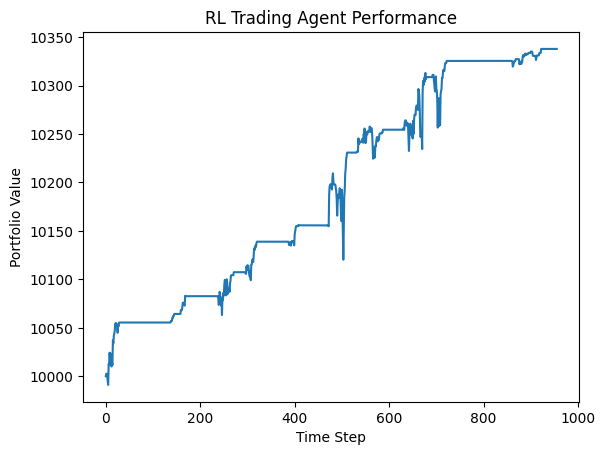

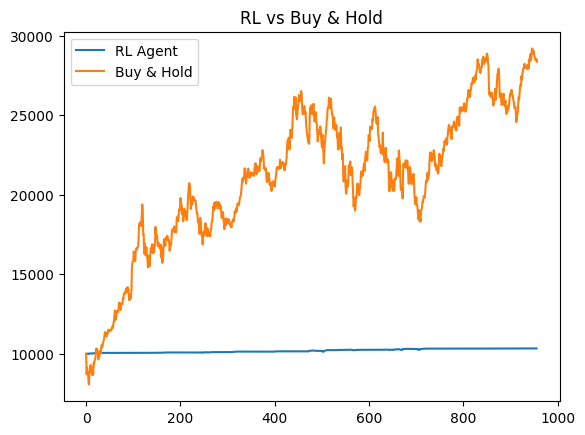

Action: 2 Balance: 10337.848197937012 Shares: 0


In [18]:
epsilon = 0
portfolio_values = []

state = env.reset()
state = discretize_state(state)

done = False

while not done:
    # choose best action (no exploration)
    q_values = get_q_values(state)
    action = np.argmax(q_values)

    next_state, reward, done = env.step(action)
    next_state = discretize_state(next_state)

    # track portfolio value
    price = float(env.data.loc[env.current_step, 'Close'])
    portfolio_value = env.balance + env.shares * price

    portfolio_values.append(portfolio_value)

    state = next_state
    import matplotlib.pyplot as plt

plt.plot(portfolio_values)
plt.title("RL Trading Agent Performance")
plt.xlabel("Time Step")
plt.ylabel("Portfolio Value")
plt.show()
buy_hold = env.data['Close'].values
buy_hold = buy_hold / buy_hold[0] * 10000  # normalize

plt.plot(portfolio_values, label="RL Agent")
plt.plot(buy_hold, label="Buy & Hold")
plt.legend()
plt.title("RL vs Buy & Hold")
plt.show()
print("Action:", action, "Balance:", env.balance, "Shares:", env.shares)